# Ender neural network: train and upload

This notebook trains the best model from the study *Train Less, Contribute More* and writes a
pickle file you can upload to Numerai Classic.

**The model.** A plain MLP (780 → 1024 → 512 → 256 → 1) trained on whole eras with a per-era
correlation loss, plus a penalty on correlation with Numerai's LightGBM benchmark. It is
trained for a fixed number of optimizer **steps**, not epochs. That was the study's main finding:
the best training amount is a step count, so the notebook keeps it fixed whatever data size you load.

**What it does.**
1. Downloads Numerai v5.3 data (medium feature set).
2. Trains on the training eras and scores CORR and BMC on held-out validation eras.
3. Retrains on training + validation eras for the final model.
4. Exports the network to plain numpy and saves `ender_nn_model.pkl` for upload.

It runs on Google Colab (GPU or CPU) or locally. The full study, code and paper are on GitHub:
[VolodymyrLinuxovich/example-scripts, branch `nn-arch-ender20`](https://github.com/VolodymyrLinuxovich/example-scripts/tree/nn-arch-ender20/numerai/agents/experiments/nn_arch_ender20).

In [1]:
# Install dependencies (PyTorch is preinstalled on Colab; it is only needed for training)
%pip install -q numerapi pyarrow cloudpickle numerai-tools matplotlib
try:
    import torch
except ImportError:
    %pip install -q torch

Note: you may need to restart the kernel to use updated packages.


## Settings

These are the study's final settings. `TOTAL_STEPS` is the training amount; each step is one
batch of `ERAS_PER_BATCH` whole eras.

In [2]:
import sys, json, math, gc, warnings
import numpy as np
import pandas as pd
import torch

DATA_VERSION = "v5.3"
FEATURE_SET = "medium"            # 780 features; "all" needs far more RAM
TARGET = "target"                 # in v5.3 this is the 60-day Ender target Numerai pays on
BENCHMARK = "v53_lgbm_ender60"    # LightGBM benchmark matching the payout target

HIDDEN = [1024, 512, 256]
DROPOUT = 0.2
LR = 2e-3
WEIGHT_DECAY = 1e-5
ERAS_PER_BATCH = 4
TOTAL_STEPS = 350                 # ~1,400 era visits: the optimum found in the study
BENCH_PENALTY = 0.3               # weight on corr(prediction, benchmark)^2 per era
N_SEEDS = 3                       # average of independently trained networks
FINAL_FIT_ON_ALL = True           # retrain on train + validation eras for the upload model
FINAL_ERA_STRIDE = 2              # use every 2nd era in the final fit to fit in ~12 GB of RAM

warnings.filterwarnings("ignore", message="The given NumPy array is not writable")
warnings.filterwarnings("ignore", message="Converting a tensor with requires_grad")
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Python {sys.version.split()[0]} · torch {torch.__version__} · device {DEVICE}")

Python 3.12.13 · torch 2.14.1 · device mps


## Download the data

In [3]:
from numerapi import NumerAPI
napi = NumerAPI()
for f in ["features.json", "train.parquet", "validation.parquet",
          "train_benchmark_models.parquet", "validation_benchmark_models.parquet", "live.parquet"]:
    napi.download_dataset(f"{DATA_VERSION}/{f}")

features = json.load(open(f"{DATA_VERSION}/features.json"))["feature_sets"][FEATURE_SET]
print(len(features), "features")

2026-10-04 21:03:36,156 INFO numerapi.utils: target file already exists


2026-10-04 21:03:36,157 INFO numerapi.utils: download complete


2026-10-04 21:03:36,539 INFO numerapi.utils: target file already exists


2026-10-04 21:03:36,539 INFO numerapi.utils: download complete


2026-10-04 21:03:36,902 INFO numerapi.utils: target file already exists


...

2026-10-04 21:03:37,510 INFO numerapi.utils: target file already exists


2026-10-04 21:03:37,511 INFO numerapi.utils: download complete


2026-10-04 21:03:37,825 INFO numerapi.utils: target file already exists


2026-10-04 21:03:37,825 INFO numerapi.utils: download complete


780 features


In [4]:
def load(split, filters=None):
    """Load features (int8), era, target and the benchmark prediction for one split."""
    df = pd.read_parquet(f"{DATA_VERSION}/{split}.parquet", columns=["era", TARGET] + features,
                         filters=filters)
    bench = pd.read_parquet(f"{DATA_VERSION}/{split}_benchmark_models.parquet", columns=[BENCHMARK])
    df[BENCHMARK] = bench[BENCHMARK].reindex(df.index)
    return df.dropna(subset=[TARGET])

train = load("train")
print(f"train: {len(train):,} rows, {train.era.nunique()} eras")

train: 2,746,268 rows, 574 eras


## The model

`EnderNet` is a plain MLP on inputs scaled to `(x − 2) / 2`. Each training step takes
`ERAS_PER_BATCH` whole eras and minimizes, per era,

$$-\,\mathrm{corr}(\hat y, y) \;+\; \lambda\,\mathrm{corr}(\hat y, b)^2,$$

where $b$ is the benchmark's prediction. The penalty pushes the network towards signal the
benchmark does not already have, which is what BMC rewards. The benchmark is used only during
training, never as an input.

In [5]:
class EnderNet(torch.nn.Module):
    def __init__(self, n_features):
        super().__init__()
        layers, d = [], n_features
        for h in HIDDEN:
            layers += [torch.nn.Linear(d, h), torch.nn.SiLU(), torch.nn.Dropout(DROPOUT)]
            d = h
        layers.append(torch.nn.Linear(d, 1))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x_int8):
        return self.net((x_int8.float() - 2.0) / 2.0).squeeze(-1)


def era_corr(p, t):
    p = p - p.mean(); t = t - t.mean()
    return (p * t).sum() / (p.norm() * t.norm() + 1e-8)


def train_networks(df, steps=TOTAL_STEPS, seeds=N_SEEDS):
    """Train `seeds` networks for a fixed number of era-batch steps. Returns numpy weights."""
    assert df["era"].is_monotonic_increasing, "rows must be grouped by era"
    x = torch.from_numpy(df[features].to_numpy(dtype=np.int8)).to(DEVICE)
    y = torch.from_numpy(df[TARGET].to_numpy(dtype=np.float32) - 0.5).to(DEVICE)
    b = torch.from_numpy(df[BENCHMARK].fillna(0.5).to_numpy(dtype=np.float32)).to(DEVICE)
    codes = pd.factorize(df["era"])[0]
    bounds = np.flatnonzero(np.diff(codes)) + 1
    starts, ends = np.r_[0, bounds], np.r_[bounds, len(codes)]
    exported = []
    for seed in range(seeds):
        torch.manual_seed(1337 + seed); rng = np.random.default_rng(1337 + seed)
        net = EnderNet(len(features)).to(DEVICE)
        opt = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        warm = max(1, steps // 20)
        sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: (s + 1) / warm if s < warm
                                                  else 0.5 * (1 + math.cos(math.pi * (s - warm) / max(1, steps - warm))))
        order, pos = rng.permutation(len(starts)), 0
        net.train()
        for step in range(steps):
            if pos + ERAS_PER_BATCH > len(order):
                order, pos = rng.permutation(len(starts)), 0
            loss = 0.0
            for e in order[pos:pos + ERAS_PER_BATCH]:
                s, t = int(starts[e]), int(ends[e])
                pred = net(x[s:t])
                loss = loss - era_corr(pred, y[s:t]) + BENCH_PENALTY * era_corr(pred, b[s:t]) ** 2
            pos += ERAS_PER_BATCH
            opt.zero_grad(); (loss / ERAS_PER_BATCH).backward(); opt.step(); sched.step()
            if (step + 1) % 50 == 0:
                print(f"  seed {seed}  step {step + 1}/{steps}  loss {loss.item() / ERAS_PER_BATCH:+.4f}")
        net.eval()
        exported.append([(m.weight.detach().cpu().numpy().astype(np.float32),
                          m.bias.detach().cpu().numpy().astype(np.float32))
                         for m in net.net if isinstance(m, torch.nn.Linear)])
    del x, y, b
    return exported

## Inference in plain numpy

Numerai runs uploaded models in its own Python environment, which may not include PyTorch. The
trained weights are exported to numpy arrays and evaluated with this small function, so the
upload pickle needs only numpy and pandas.

In [6]:
def numpy_forward(weights, x_int8):
    h = (x_int8.astype(np.float32) - 2.0) / 2.0
    # numpy 2.x on macOS can emit spurious float warnings in matmul; outputs are checked below
    with np.errstate(all="ignore"):
        for i, (w, bias) in enumerate(weights):
            h = h @ w.T + bias
            if i < len(weights) - 1:
                h = h / (1.0 + np.exp(-h))   # SiLU
    if not np.isfinite(h).all():
        raise ValueError("non-finite network output")
    return h[:, 0]


def ensemble_predict(networks, x_int8, batch=50_000):
    out = np.zeros(len(x_int8))
    for weights in networks:
        out += np.concatenate([numpy_forward(weights, x_int8[i:i + batch])
                               for i in range(0, len(x_int8), batch)])
    return out / len(networks)

## Train on the training eras

In [7]:
networks = train_networks(train)
last_train_era = int(train["era"].max())
del train; _ = gc.collect()

  seed 0  step 50/350  loss -0.0660


  seed 0  step 100/350  loss -0.0747


  seed 0  step 150/350  loss -0.1112


  seed 0  step 200/350  loss -0.1578


  seed 0  step 250/350  loss -0.2205


...

  seed 2  step 150/350  loss -0.1033


  seed 2  step 200/350  loss -0.1452


  seed 2  step 250/350  loss -0.1788


  seed 2  step 300/350  loss -0.2157


  seed 2  step 350/350  loss -0.1953


## Validate on held-out eras

The target looks 60 days ahead, so the 12 eras after the last training era are skipped to avoid
leakage. BMC is the correlation with the target after neutralizing the prediction against the
benchmark: the signal this model adds beyond it.

In [8]:
from numerai_tools.scoring import numerai_corr, correlation_contribution

embargo = [str(last_train_era + i).zfill(4) for i in range(1, 13)]
validation = load("validation", filters=[("data_type", "==", "validation"), ("era", "not in", embargo)])
validation["prediction"] = ensemble_predict(networks, validation[features].to_numpy(dtype=np.int8))

scored = validation.dropna(subset=[BENCHMARK])
corr = scored.groupby("era")[["prediction", TARGET]].apply(
    lambda d: numerai_corr(d[["prediction"]], d[TARGET])).iloc[:, 0]
bmc = scored.groupby("era")[["prediction", BENCHMARK, TARGET]].apply(
    lambda d: correlation_contribution(d[["prediction"]], d[BENCHMARK], d[TARGET])).iloc[:, 0]
bench_corr = scored.groupby("era").apply(lambda d: d["prediction"].corr(d[BENCHMARK], method="spearman"))

summary = pd.DataFrame({
    "mean": [corr.mean(), bmc.mean(), bmc.tail(200).mean(), bench_corr.mean()],
    "sharpe": [corr.mean() / corr.std(), bmc.mean() / bmc.std(), bmc.tail(200).mean() / bmc.tail(200).std(), np.nan],
}, index=["CORR", "BMC", "BMC (last 200 eras)", "corr with benchmark"])
summary.round(4)

,mean,sharpe
CORR,0.0176,1.0445
BMC,0.0044,0.3169
BMC (last 200 eras),0.0062,0.4198
corr with benchmark,0.2299,NaN


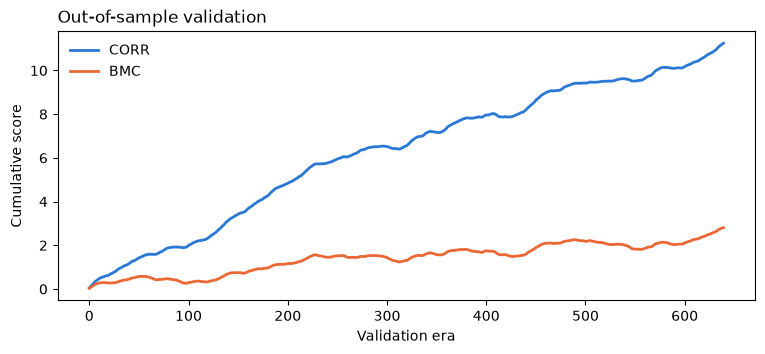

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(corr.cumsum().values, label="CORR", color="#2a78d6", lw=2)
ax.plot(bmc.cumsum().values, label="BMC", color="#eb6834", lw=2)
ax.set_xlabel("Validation era"); ax.set_ylabel("Cumulative score"); ax.legend(frameon=False)
ax.set_title("Out-of-sample validation", loc="left")
plt.show()
del validation, scored; _ = gc.collect()

## Final model

Retrain on train + validation eras (every `FINAL_ERA_STRIDE`-th era, to fit in Colab's RAM)
with the same number of steps. Because the training amount is fixed in steps, more data does not
mean over-training.

In [10]:
if FINAL_FIT_ON_ALL:
    all_eras = sorted(set(pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"])["era"])
                      | set(pd.read_parquet(f"{DATA_VERSION}/validation.parquet", columns=["era"],
                                            filters=[("data_type", "==", "validation")])["era"]))
    keep = all_eras[::-1][::FINAL_ERA_STRIDE][::-1]   # newest era always included
    full = pd.concat([load("train", filters=[("era", "in", keep)]),
                      load("validation", filters=[("data_type", "==", "validation"), ("era", "in", keep)])])
    print(f"final fit: {len(full):,} rows, {full.era.nunique()} eras")
    networks = train_networks(full)
    del full; _ = gc.collect()

final fit: 3,410,019 rows, 613 eras


  seed 0  step 50/350  loss -0.0118


  seed 0  step 100/350  loss -0.0440


  seed 0  step 150/350  loss -0.0443


  seed 0  step 200/350  loss -0.0623


...

  seed 2  step 150/350  loss -0.0371


  seed 2  step 200/350  loss -0.0638


  seed 2  step 250/350  loss -0.0700


  seed 2  step 300/350  loss -0.0753


  seed 2  step 350/350  loss -0.1104


## Predict live data and build the upload file

In [11]:
def predict(live_features: pd.DataFrame, live_benchmark_models: pd.DataFrame | None = None) -> pd.DataFrame:
    x = live_features[FEATURES].fillna(2).to_numpy(dtype=np.int8)
    raw = ensemble_predict(NETWORKS, x)
    ranked = pd.Series(raw, index=live_features.index).rank(pct=True)
    return ranked.to_frame("prediction")

# Bind the trained weights and feature list into the function's globals for pickling
FEATURES, NETWORKS = list(features), networks

live = pd.read_parquet(f"{DATA_VERSION}/live.parquet")
live_predictions = predict(live)
print(live_predictions.describe().T)

             count      mean       std       min       25%       50%  \
prediction  6908.0  0.500072  0.288696  0.000145  0.250109  0.500072   

                 75%  max  
prediction  0.750036  1.0  


In [12]:
import cloudpickle
with open("ender_nn_model.pkl", "wb") as f:
    cloudpickle.dump(predict, f)

# Check the file loads and predicts without this notebook's state
import pickle
reloaded = pickle.load(open("ender_nn_model.pkl", "rb"))
assert np.allclose(reloaded(live)["prediction"], live_predictions["prediction"])
import os
print(f"ender_nn_model.pkl: {os.path.getsize('ender_nn_model.pkl') / 1e6:.1f} MB, built with Python {sys.version.split()[0]}")

ender_nn_model.pkl: 17.5 MB, built with Python 3.12.13


## Upload

1. Go to [numer.ai](https://numer.ai) → **Models**, create a model (or pick one) and choose
   **Upload model**.
2. Upload `ender_nn_model.pkl`.
3. Pick the runtime whose Python version matches the one printed above (Numerai offers 3.10–3.13;
   the default is 3.12). A pickled function only loads in the same Python version it was built with.

Numerai then runs `predict` on each new round's live data automatically.